# Visualizing the input data and output features of a DNN classifcation model with t-SNE

t-distributed stochastic neighbor embedding (t-SNE) is a nonlinear dimensionality reduction technique for visualizing high-dimensional data in a two or three-dimensional map.

In this notebook we use the modified ResNet-18 model and the Fashion MNIST dataset.

## Import the necessary libraries

In [12]:
## Standard libraries
import os
import numpy as np

## PyTorch & Torchvision
import torch
import torchvision
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import DataLoader

## Imports for plotting
import matplotlib.pyplot as plt
import matplotlib.cm as cm

## import t-SNE function
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from tqdm import tqdm

In [2]:
# Decide which device we want to run on
device = (
    "cuda"
    if  (torch.cuda.is_available())
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

#Additional Info when using cuda
if device == 'cuda':
    print('Number of GPU(s):', torch.cuda.device_count())
    print('GPU device(s):', torch.cuda.get_device_name(0))

Using cuda device
Number of GPU(s): 1
GPU device(s): NVIDIA GeForce GTX 1650 with Max-Q Design


##  Parameters

In [3]:
# Paths to data and model weigths directories
dataset_path = ""
model_weigths_path = ""

# Data loader parameters
num_threads = round(os.cpu_count()/2)   # Loading the dataset using (total_CPU/2) CPU threads
reduce_rate = 10   # Ratio to reduce the dataset size

# t-SNE parameters
n_cp = 2 # Dimension of the embedded space
perplexity= 30 # The perplexity is related to the number of nearest neighbors

## Dataset

We use the fashion dataset of zalando which is made of :
- 60000 28x28 grayscale images in the training set
- 10000 28x28 grayscale images in the test set
- belonging to 10 classes (Tshirt, Trouser, Pullover, Dress, Coat, Sandal, Shift, Sneaker, Bag, Ankle boot)

<img src="Classes-in-the-Zalando-Fashion-Dataset.png" alt="Fashion MNIST classes" width="400" />

This datset is managed directly by PyTorch.


### Define the data loader for Fashion MNIST

In this notbook we only use the test set.

In [4]:
def get_data_test(dataset_dir, num_threads=0, reduce_rate=1):

    # Define the transforms applied to the inputed data
    fashion_mnist = torchvision.datasets.FashionMNIST(download=True, train=True, root=dataset_dir).train_data.float()
    
    data_transform = transforms.Compose([transforms.Resize((224, 224)),
                                         transforms.ToTensor(), 
                                         transforms.Normalize((fashion_mnist.mean()/255,), (fashion_mnist.std()/255,))])

   
    # Load the data realted to the test set
    data = torchvision.datasets.FashionMNIST(download=True, root=dataset_dir, transform=data_transform, train=False)

    # Get the name of the classes
    class_names = data.classes
    
    print("class names and associated index")
    print(data.class_to_idx)
    
    # Reduce the amount of data -> reduce the memory size and the computational time
    torch.manual_seed(0) # to select the same data at each run
    data_limit_len = round(len(data) /reduce_rate)
    data_reduced, tr = torch.utils.data.random_split(data, [data_limit_len, len(data)-data_limit_len])

    test_loader=DataLoader(data_reduced, batch_size=len(data_reduced), num_workers=num_threads)
    
    return test_loader, class_names

### Load the data

In [5]:
# load the data
test_loader, class_names = get_data_test(dataset_path, num_threads, reduce_rate)

num_classes=len(class_names)

print("The test set contains {} images, in {} batches".format(len(test_loader.dataset), len(test_loader)))

C:\Users\bocca\anaconda3\Lib\site-packages\torchvision\datasets\mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")


class names and associated index
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}
The test set contains 1000 images, in 1 batches


## Define the modified ResNet model and load the trained weights

### Modified ResNet model



In [6]:
my_resnet = models.resnet18(num_classes=10).to(device)
my_resnet.conv1 = torch.nn.Conv2d(1, my_resnet.conv1.out_channels, kernel_size=my_resnet.conv1.kernel_size, stride=my_resnet.conv1.stride, padding=my_resnet.conv1.padding, bias=my_resnet.conv1.bias)

### Loading the trained weights

In [7]:
my_resnet.load_state_dict(torch.load(model_weigths_path + "resnet18_fine_tuned2_MNIST.pth"))

C:\Users\bocca\AppData\Local\Temp\ipykernel_34576\1520950993.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  my_resnet.load_state_dict(torch.load(model_weigths_path + "r

<All keys matched successfully>

## Visualize the data using t-SNE

Information about the sklearn t-SNE fonction can be found [here](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)


### t-SNE of the raw data

In [9]:
# Extraire les images et labels depuis test_loader
raw_images = []
labels = []

for images, target in tqdm(test_loader):
    raw_images.append(images.view(images.shape[0], -1).cpu().numpy())  # Aplatir les images en vecteurs
    labels.append(target.cpu().numpy())

# Convertir en numpy array
raw_images = np.concatenate(raw_images, axis=0)
labels = np.concatenate(labels, axis=0)

print(f"Raw Images shape: {raw_images.shape}, Labels shape: {labels.shape}")

# Appliquer t-SNE sur les images brutes
tsne_raw = TSNE(n_components=2, perplexity=30, random_state=42)
raw_features_2d = tsne_raw.fit_transform(raw_images)

100%|██████████| 1/1 [00:07<00:00,  7.16s/it]


Raw Images shape: (1000, 50176), Labels shape: (1000,)


Display the result

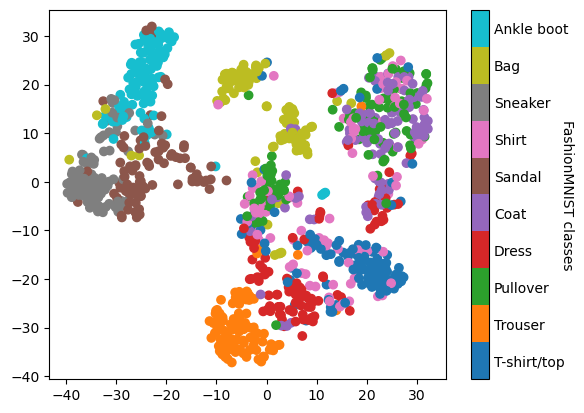

In [10]:
plt.scatter(raw_features_2d[:, 0], raw_features_2d[:, 1], c=labels, cmap='tab10')
cbar = plt.colorbar()

# calculate tick positions 
# (so that each ticklabel can be placed in the center of its color)
yticks = np.linspace(*cbar.ax.get_ylim(), num_classes+1)[:-1]
yticks += (yticks[1] - yticks[0]) / 2

# add tick labels to colorbar
cbar.set_ticks(yticks, labels=class_names)
cbar.ax.tick_params(length=0)          # remove tick lines


# add label
cbar.set_label('FashionMNIST classes', rotation=270)

plt.show()

### t-SNE of the deep (last layer) features

In [21]:
# Assurez-vous que le modèle est en mode évaluation
my_resnet.eval()
my_resnet.to(device)
deep_features = []
labels = []

# Désactiver le calcul du gradient (inférence)
with torch.no_grad():
    for images, target in tqdm(test_loader):
        images = images.to(device)  # Passer sur GPU si dispo
        target = target.cpu().numpy()  # Récupérer les labels
        
        # Extraire les features de la dernière couche cachée
        output = my_resnet(images)  # Assurez-vous que cette sortie est bien celle des features
        output = output.cpu().numpy()

        deep_features.append(output)
        labels.append(target)

# Convertir en numpy array
deep_features = np.concatenate(deep_features, axis=0)
labels = np.concatenate(labels, axis=0)

print(f"Deep Features shape: {deep_features.shape}, Labels shape: {labels.shape}")

# Réduction avec t-SNE
tsne_deep = TSNE(n_components=2, perplexity=30, random_state=42)
deep_features_2d = tsne_deep.fit_transform(deep_features)

100%|██████████| 1/1 [01:56<00:00, 116.40s/it]


Deep Features shape: (1000, 10), Labels shape: (1000,)


Display the result

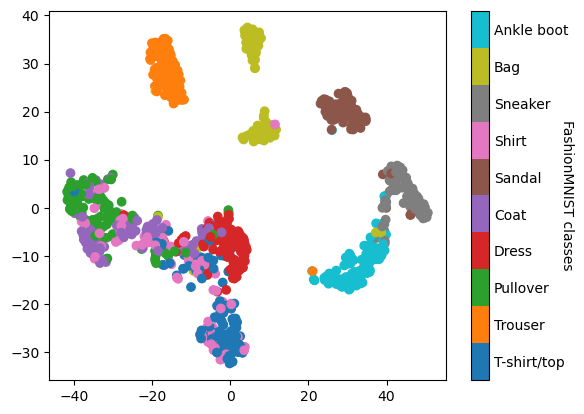

In [22]:
plt.scatter(deep_features_2d[:, 0], deep_features_2d[:, 1], c=labels, cmap='tab10')
cbar = plt.colorbar()

# calculate tick positions 
# (so that each ticklabel can be placed in the center of its color)
yticks = np.linspace(*cbar.ax.get_ylim(), num_classes+1)[:-1]
yticks += (yticks[1] - yticks[0]) / 2

# add tick labels to colorbar
cbar.set_ticks(yticks, labels=class_names)
cbar.ax.tick_params(length=0)          # remove tick lines


# add label
cbar.set_label('FashionMNIST classes', rotation=270)

plt.show()

## Work to do

1- Study the effect of t-SNE function parameters

2- Display t-SNE of ResNet outputs learned from scratch. Compare the results.

3- Apply PCA instead of t-SNE.

100%|██████████| 1/1 [01:06<00:00, 66.82s/it]


Deep Features shape: (1000, 10), Labels shape: (1000,)


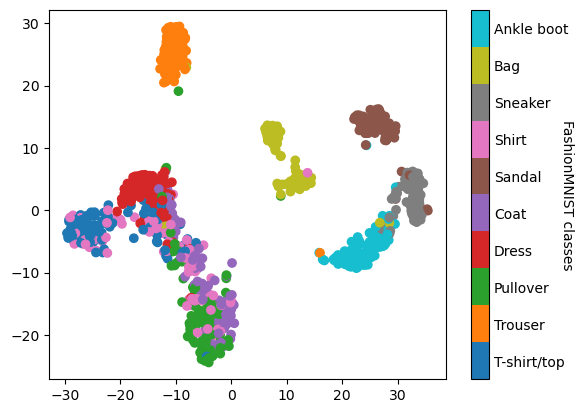

In [8]:
# Assurez-vous que le modèle est en mode évaluation
my_resnet.eval()
my_resnet.to(device)
deep_features = []
labels = []

# Désactiver le calcul du gradient (inférence)
with torch.no_grad():
    for images, target in tqdm(test_loader):
        images = images.to(device)  # Passer sur GPU si dispo
        target = target.cpu().numpy()  # Récupérer les labels
        
        # Extraire les features de la dernière couche cachée
        output = my_resnet(images)  # Assurez-vous que cette sortie est bien celle des features
        output = output.cpu().numpy()

        deep_features.append(output)
        labels.append(target)

# Convertir en numpy array
deep_features = np.concatenate(deep_features, axis=0)
labels = np.concatenate(labels, axis=0)

print(f"Deep Features shape: {deep_features.shape}, Labels shape: {labels.shape}")

# Réduction avec t-SNE
tsne_deep = TSNE(n_components=2, perplexity=50, random_state=42)
deep_features_2d = tsne_deep.fit_transform(deep_features)

plt.scatter(deep_features_2d[:, 0], deep_features_2d[:, 1], c=labels, cmap='tab10')
cbar = plt.colorbar()

# calculate tick positions 
# (so that each ticklabel can be placed in the center of its color)
yticks = np.linspace(*cbar.ax.get_ylim(), num_classes+1)[:-1]
yticks += (yticks[1] - yticks[0]) / 2

# add tick labels to colorbar
cbar.set_ticks(yticks, labels=class_names)
cbar.ax.tick_params(length=0)          # remove tick lines


# add label
cbar.set_label('FashionMNIST classes', rotation=270)

plt.show()

100%|██████████| 1/1 [01:00<00:00, 60.06s/it]


Deep Features shape: (1000, 10), Labels shape: (1000,)


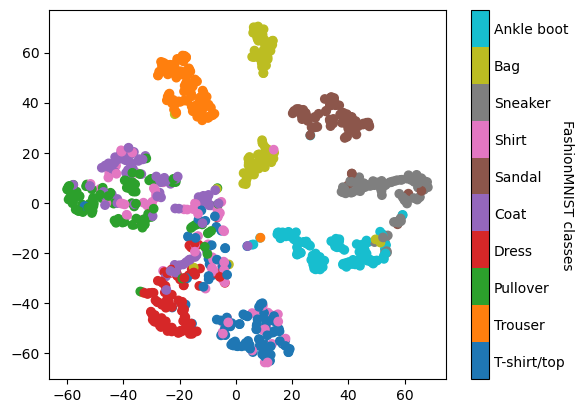

In [9]:
# Assurez-vous que le modèle est en mode évaluation
my_resnet.eval()
my_resnet.to(device)
deep_features = []
labels = []

# Désactiver le calcul du gradient (inférence)
with torch.no_grad():
    for images, target in tqdm(test_loader):
        images = images.to(device)  # Passer sur GPU si dispo
        target = target.cpu().numpy()  # Récupérer les labels
        
        # Extraire les features de la dernière couche cachée
        output = my_resnet(images)  # Assurez-vous que cette sortie est bien celle des features
        output = output.cpu().numpy()

        deep_features.append(output)
        labels.append(target)

# Convertir en numpy array
deep_features = np.concatenate(deep_features, axis=0)
labels = np.concatenate(labels, axis=0)

print(f"Deep Features shape: {deep_features.shape}, Labels shape: {labels.shape}")

# Réduction avec t-SNE
tsne_deep = TSNE(n_components=2, perplexity=10, random_state=42)
deep_features_2d = tsne_deep.fit_transform(deep_features)

plt.scatter(deep_features_2d[:, 0], deep_features_2d[:, 1], c=labels, cmap='tab10')
cbar = plt.colorbar()

# calculate tick positions 
# (so that each ticklabel can be placed in the center of its color)
yticks = np.linspace(*cbar.ax.get_ylim(), num_classes+1)[:-1]
yticks += (yticks[1] - yticks[0]) / 2

# add tick labels to colorbar
cbar.set_ticks(yticks, labels=class_names)
cbar.ax.tick_params(length=0)          # remove tick lines


# add label
cbar.set_label('FashionMNIST classes', rotation=270)

plt.show()

In [10]:
my_resnet2 = models.resnet18(num_classes=10).to(device)
my_resnet2.conv1 = torch.nn.Conv2d(1, my_resnet2.conv1.out_channels, kernel_size=my_resnet2.conv1.kernel_size, stride=my_resnet2.conv1.stride, padding=my_resnet2.conv1.padding, bias=my_resnet2.conv1.bias)
my_resnet2.load_state_dict(torch.load(model_weigths_path + "resnet18_from_scratch_MNIST.pth"))

C:\Users\bocca\AppData\Local\Temp\ipykernel_34576\2491901885.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  my_resnet2.load_state_dict(torch.load(model_weigths_path + "

<All keys matched successfully>

100%|██████████| 1/1 [00:40<00:00, 40.85s/it]


Deep Features shape: (1000, 10), Labels shape: (1000,)


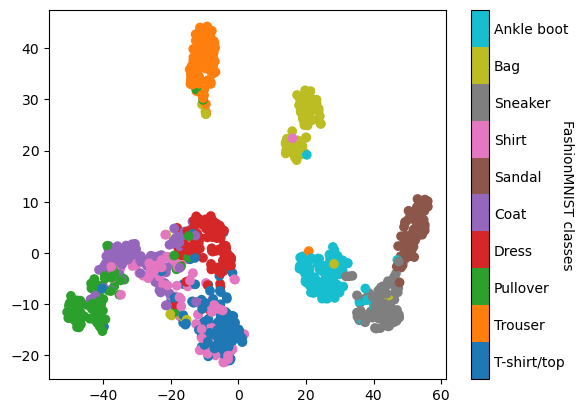

In [11]:
# Assurez-vous que le modèle est en mode évaluation
my_resnet2.eval()
my_resnet2.to(device)
deep_features = []
labels = []

# Désactiver le calcul du gradient (inférence)
with torch.no_grad():
    for images, target in tqdm(test_loader):
        images = images.to(device)  # Passer sur GPU si dispo
        target = target.cpu().numpy()  # Récupérer les labels
        
        # Extraire les features de la dernière couche cachée
        output = my_resnet2(images)  # Assurez-vous que cette sortie est bien celle des features
        output = output.cpu().numpy()

        deep_features.append(output)
        labels.append(target)

# Convertir en numpy array
deep_features = np.concatenate(deep_features, axis=0)
labels = np.concatenate(labels, axis=0)

print(f"Deep Features shape: {deep_features.shape}, Labels shape: {labels.shape}")

# Réduction avec t-SNE
tsne_deep = TSNE(n_components=2, perplexity=30, random_state=42)
deep_features_2d = tsne_deep.fit_transform(deep_features)

plt.scatter(deep_features_2d[:, 0], deep_features_2d[:, 1], c=labels, cmap='tab10')
cbar = plt.colorbar()

# calculate tick positions 
# (so that each ticklabel can be placed in the center of its color)
yticks = np.linspace(*cbar.ax.get_ylim(), num_classes+1)[:-1]
yticks += (yticks[1] - yticks[0]) / 2

# add tick labels to colorbar
cbar.set_ticks(yticks, labels=class_names)
cbar.ax.tick_params(length=0)          # remove tick lines


# add label
cbar.set_label('FashionMNIST classes', rotation=270)

plt.show()

In [ ]:
# Assurez-vous que le modèle est en mode évaluation
my_resnet.eval()
my_resnet.to(device)
deep_features = []
labels = []

# Désactiver le calcul du gradient (inférence)
with torch.no_grad():
    for images, target in tqdm(test_loader):
        images = images.to(device)  # Passer sur GPU si dispo
        target = target.cpu().numpy()  # Récupérer les labels
        
        # Extraire les features de la dernière couche cachée
        output = my_resnet(images)  # Assurez-vous que cette sortie est bien celle des features
        output = output.cpu().numpy()

        deep_features.append(output)
        labels.append(target)

# Convertir en numpy array
deep_features = np.concatenate(deep_features, axis=0)
labels = np.concatenate(labels, axis=0)

print(f"Deep Features shape: {deep_features.shape}, Labels shape: {labels.shape}")


# Appliquer la PCA pour réduire à 2 dimensions
pca = PCA(n_components=2)
pca_result = pca.fit_transform(deep_features)

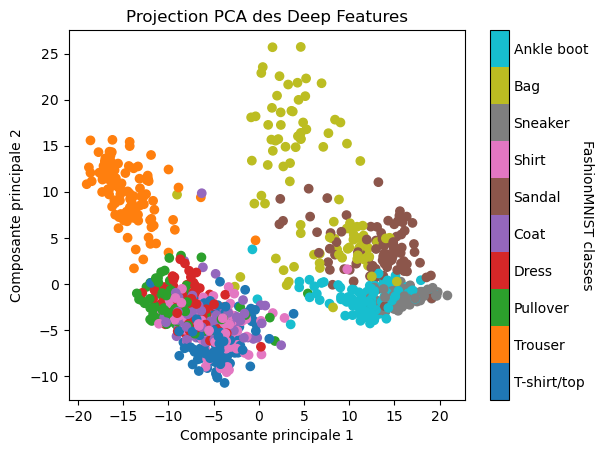

In [14]:
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=labels, cmap='tab10')
cbar = plt.colorbar()

# calculate tick positions 
# (so that each ticklabel can be placed in the center of its color)
yticks = np.linspace(*cbar.ax.get_ylim(), num_classes+1)[:-1]
yticks += (yticks[1] - yticks[0]) / 2

# add tick labels to colorbar
cbar.set_ticks(yticks, labels=class_names)
cbar.ax.tick_params(length=0)          # remove tick lines
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Projection PCA des Deep Features")

# add label
cbar.set_label('FashionMNIST classes', rotation=270)

plt.show()